There are 2 types of Edges/flows:
1. Sequential edge
2. Conditional edge / Conditional flows.

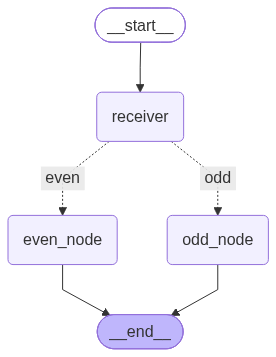

In [2]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class NumberState(TypedDict):
    number: int
    result: str

def receive_number(state: NumberState) -> dict:
    print(f"received number:: ", state["number"])
    return {}

def route_even_or_odd(state: NumberState) -> Literal["even", "odd"]:
    if state["number"] % 2 ==0:
        return "even"
    else:
        return "odd"

def even_node(state: NumberState) -> dict:
    msg = f"{state["number"]} is EVEN"
    print(f"[even_node] {msg}")
    return {"result": msg}

def odd_node(state: NumberState) -> dict:
    msg = f"{state["number"]} is ODD"
    print(f"[odd_node] {msg}")
    return {"result": msg}

builder = StateGraph(NumberState)

builder.add_node("receiver", receive_number)
builder.add_node("even_node", even_node)
builder.add_node("odd_node", odd_node)

builder.add_edge(START, "receiver")
builder.add_conditional_edges(
    "receiver", 
    route_even_or_odd,
    {"even":"even_node", "odd": "odd_node"}
)
builder.add_edge("even_node", END)
builder.add_edge("odd_node", END)

graph = builder.compile()

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)